# Feature Selection

Feature Selection is the process of identifying the most informative variables for model training.

The objectives of this notebook are:

- Remove irrelevant features.
- Reduce redundancy.
- Improve model performance.
- Reduce overfitting.
- Build a compact feature set for machine learning.

## import libraries ##

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import (
    VarianceThreshold,
    mutual_info_classif,
    SelectKBest
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import RFE

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

## Load dataset ##

In [3]:
df = pd.read_csv("../data/processed/engineered_data.csv")

print(df.shape)

df.head()

(101766, 46)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_visits,active_medications,changed_medications
0,Caucasian,Female,5,6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0,0,0,0
1,Caucasian,Female,15,1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,1,0,1,1
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0,3,1,0
3,Caucasian,Male,35,1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0,0,1,1
4,Caucasian,Male,45,1,1,7,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0,0,2,0


## Cell 4 — Separate Features and Target ##

In [4]:
X = df.drop(columns=["readmitted"])

y = df["readmitted"]

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

Features Shape : (101766, 45)
Target Shape   : (101766,)


## Cell 5 — Dataset Information ##

In [5]:
print("="*60)
print("Dataset Information")
print("="*60)

print(f"Number of samples : {df.shape[0]}")
print(f"Number of features: {df.shape[1]-1}")
print(f"Target column     : readmitted")

Dataset Information
Number of samples : 101766
Number of features: 45
Target column     : readmitted


## Cell 6 — Missing Values Check ##

In [6]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

race      2273
diag_3    1423
diag_2     358
diag_1      21
dtype: int64

## Cell 7 — Feature Types ##

In [7]:
feature_summary = pd.DataFrame({
    "Data Type": X.dtypes,
    "Missing Values": X.isnull().sum(),
    "Unique Values": X.nunique()
})

feature_summary.head(15)

,Data Type,Missing Values,Unique Values
race,object,2273,5
gender,object,0,3
age,int64,0,10
admission_type_id,int64,0,8
discharge_disposition_id,int64,0,26
admission_source_id,int64,0,17
time_in_hospital,int64,0,14
num_lab_procedures,int64,0,118
num_procedures,int64,0,7
num_medications,int64,0,75


## Cell 8 — Numerical & Categorical Features ##

In [8]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features : 15
Categorical Features : 30


## Correlation Matrix (Numerical Features) ##

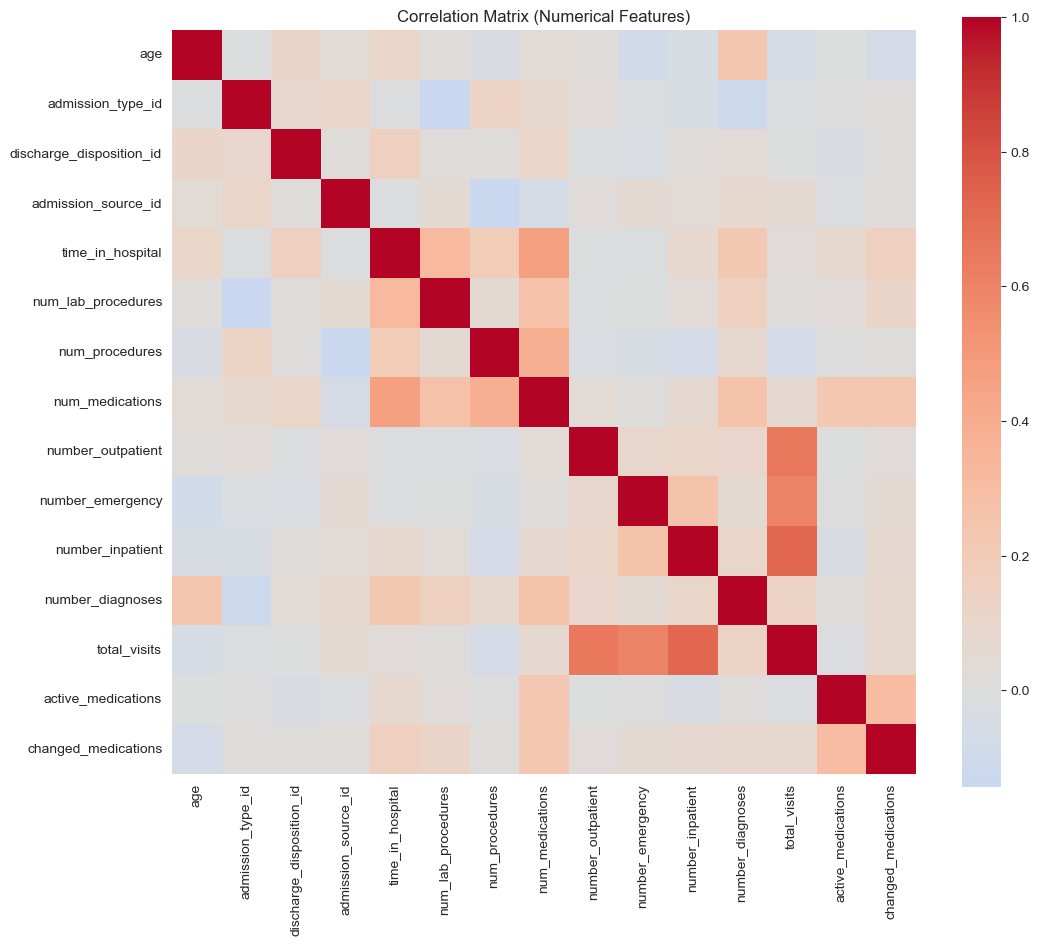

In [9]:
corr_matrix = X[numerical_features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix (Numerical Features)")
plt.show()

## Cell 10 — Highly Correlated Features ##

In [10]:
correlation_threshold = 0.90

corr_matrix = X[numerical_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

print(f"Highly Correlated Features ({len(high_corr_features)}):")

for feature in high_corr_features:
    print(feature)

Highly Correlated Features (0):


## Cell 11 — Create Encoded Copy for Feature Selection ##

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the feature set
X_encoded = X.copy()

# Encode categorical features only for feature selection
label_encoders = {}

for column in categorical_features:
    le = LabelEncoder()

    X_encoded[column] = le.fit_transform(
        X_encoded[column].astype(str)
    )

    label_encoders[column] = le

print("Categorical features encoded successfully.")
print(f"Encoded dataset shape: {X_encoded.shape}")

Categorical features encoded successfully.
Encoded dataset shape: (101766, 45)


## Cell 12 — Random Forest Feature Importance ##

In [12]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_encoded, y)

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,num_lab_procedures,0.096138
13,diag_1,0.091420
14,diag_2,0.090700
15,diag_3,0.088784
9,num_medications,0.084083
6,time_in_hospital,0.061048
2,age,0.050854
4,discharge_disposition_id,0.043030
16,number_diagnoses,0.040262
8,num_procedures,0.039760


## Cell 13 — Top 20 Important Features ##

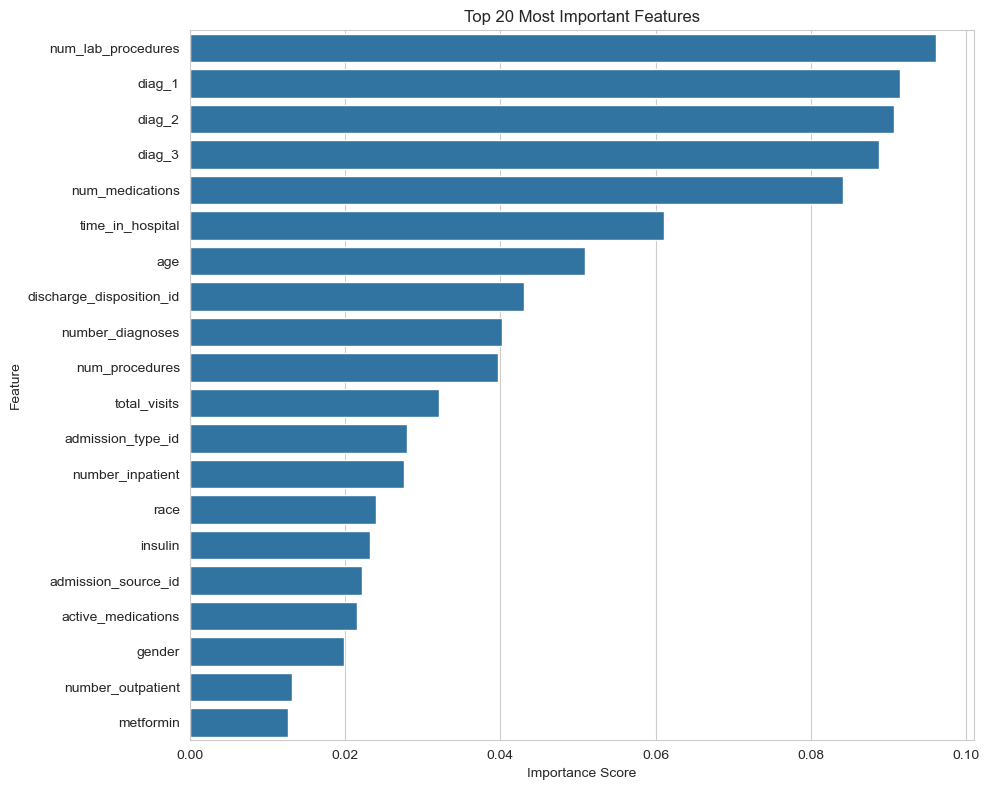

In [13]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## save importance table ##

In [14]:
feature_importance.reset_index(drop=True, inplace=True)

feature_importance.head(20)

,Feature,Importance
0,num_lab_procedures,0.096138
1,diag_1,0.091420
2,diag_2,0.090700
3,diag_3,0.088784
4,num_medications,0.084083
5,time_in_hospital,0.061048
6,age,0.050854
7,discharge_disposition_id,0.043030
8,number_diagnoses,0.040262
9,num_procedures,0.039760


## Cell 15 — Calculate Mutual Information ##

In [15]:
from sklearn.feature_selection import mutual_info_classif

# Calculate Mutual Information scores
mi_scores = mutual_info_classif(
    X_encoded,
    y,
    random_state=42
)

mi_scores = pd.DataFrame({
    "Feature": X_encoded.columns,
    "MI Score": mi_scores
})

mi_scores = mi_scores.sort_values(
    by="MI Score",
    ascending=False
)

mi_scores.head(20)

,Feature,MI Score
42,total_visits,0.031342
12,number_inpatient,0.029519
4,discharge_disposition_id,0.020734
13,diag_1,0.019346
21,glimepiride,0.015330
28,acarbose,0.013264
14,diag_2,0.013092
15,diag_3,0.012920
5,admission_source_id,0.012158
0,race,0.011351


## Cell 16 — Visualize Top 20 Features ##

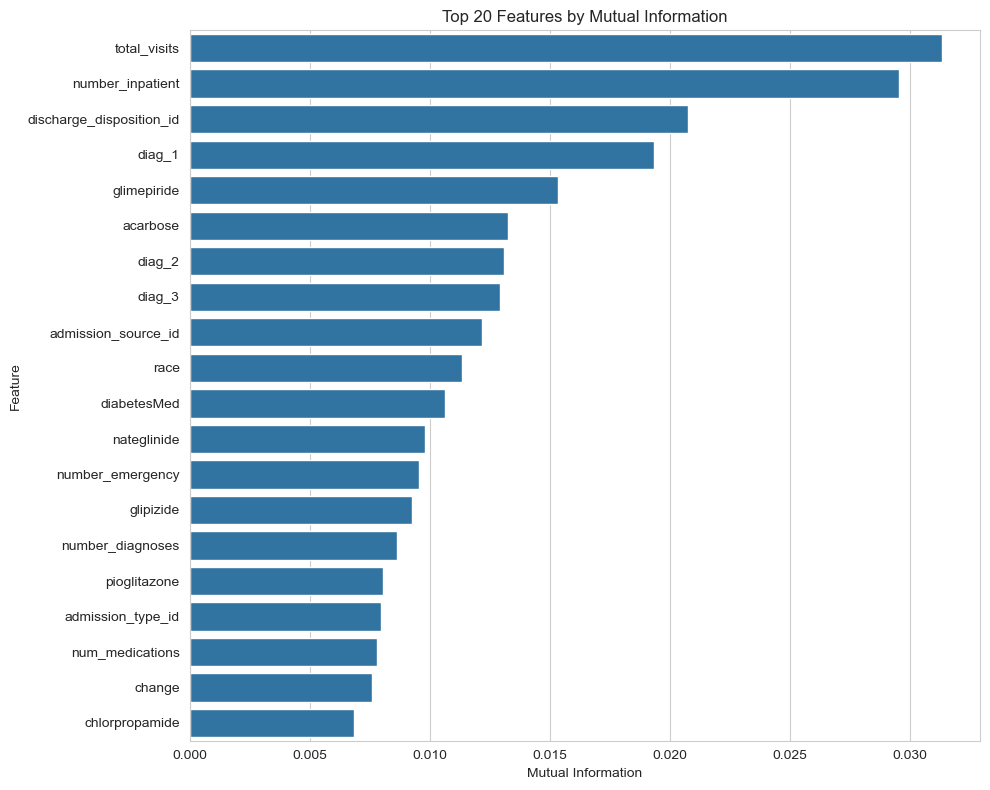

In [16]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=mi_scores.head(20),
    x="MI Score",
    y="Feature"
)

plt.title("Top 20 Features by Mutual Information")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

## Cell 17 — Compare Random Forest & Mutual Information ##

In [17]:
comparison = feature_importance.merge(
    mi_scores,
    on="Feature"
)

comparison = comparison.sort_values(
    by=["Importance", "MI Score"],
    ascending=False
)

comparison.head(20)

,Feature,Importance,MI Score
0,num_lab_procedures,0.096138,0.001511
1,diag_1,0.091420,0.019346
2,diag_2,0.090700,0.013092
3,diag_3,0.088784,0.012920
4,num_medications,0.084083,0.007795
5,time_in_hospital,0.061048,0.001749
6,age,0.050854,0.005754
7,discharge_disposition_id,0.043030,0.020734
8,number_diagnoses,0.040262,0.008617
9,num_procedures,0.039760,0.000442


## Cell 18 — Features with Very Low Importance ##

In [18]:
low_importance = comparison[
    (comparison["Importance"] < 0.005) &
    (comparison["MI Score"] < 0.005)
]

print(f"Number of low-importance features: {len(low_importance)}")

low_importance

Number of low-importance features: 11


,Feature,Importance,MI Score
29,repaglinide,3.086043e-03,0.004400
34,tolazamide,1.095279e-04,0.000000
36,tolbutamide,5.469480e-05,0.000000
37,glipizide-metformin,3.416492e-05,0.002825
38,troglitazone,9.466587e-06,0.000722
39,acetohexamide,5.985557e-06,0.000000
40,glimepiride-pioglitazone,2.802747e-06,0.001547
41,metformin-rosiglitazone,1.319938e-06,0.004302
42,metformin-pioglitazone,3.917554e-07,0.000000
44,examide,0.000000e+00,0.000854


## Cell 19 — Review Candidate Features ##

In [19]:
print("=" * 60)
print("Highly Correlated Features")
print("=" * 60)

print(high_corr_features)

print("\n")

print("=" * 60)
print("Low Importance Features")
print("=" * 60)

display(low_importance)

Highly Correlated Features
[]


Low Importance Features


,Feature,Importance,MI Score
29,repaglinide,3.086043e-03,0.004400
34,tolazamide,1.095279e-04,0.000000
36,tolbutamide,5.469480e-05,0.000000
37,glipizide-metformin,3.416492e-05,0.002825
38,troglitazone,9.466587e-06,0.000722
39,acetohexamide,5.985557e-06,0.000000
40,glimepiride-pioglitazone,2.802747e-06,0.001547
41,metformin-rosiglitazone,1.319938e-06,0.004302
42,metformin-pioglitazone,3.917554e-07,0.000000
44,examide,0.000000e+00,0.000854


## Cell 20 — Manual Selection ##

In [20]:
selected_features = comparison[
    comparison["Importance"] >= 0.005
]["Feature"].tolist()

print(f"Selected Features: {len(selected_features)}")
selected_features

Selected Features: 28


['num_lab_procedures',
 'diag_1',
 'diag_2',
 'diag_3',
 'num_medications',
 'time_in_hospital',
 'age',
 'discharge_disposition_id',
 'number_diagnoses',
 'num_procedures',
 'total_visits',
 'admission_type_id',
 'number_inpatient',
 'race',
 'insulin',
 'admission_source_id',
 'active_medications',
 'gender',
 'number_outpatient',
 'metformin',
 'glipizide',
 'glyburide',
 'number_emergency',
 'changed_medications',
 'change',
 'pioglitazone',
 'rosiglitazone',
 'glimepiride']

In [21]:
removed_features = sorted(
    list(set(X.columns) - set(selected_features))
)

print(f"Removed Features: {len(removed_features)}")

removed_features

Removed Features: 17


['acarbose',
 'acetohexamide',
 'chlorpropamide',
 'citoglipton',
 'diabetesMed',
 'examide',
 'glimepiride-pioglitazone',
 'glipizide-metformin',
 'glyburide-metformin',
 'metformin-pioglitazone',
 'metformin-rosiglitazone',
 'miglitol',
 'nateglinide',
 'repaglinide',
 'tolazamide',
 'tolbutamide',
 'troglitazone']

## Cell 22 — Build Final Dataset ##

In [22]:
selected_df = df[selected_features + ["readmitted"]]

print(selected_df.shape)

selected_df.head()

(101766, 29)


,num_lab_procedures,diag_1,diag_2,diag_3,num_medications,time_in_hospital,age,discharge_disposition_id,number_diagnoses,num_procedures,total_visits,admission_type_id,number_inpatient,race,insulin,admission_source_id,active_medications,gender,number_outpatient,metformin,glipizide,glyburide,number_emergency,changed_medications,change,pioglitazone,rosiglitazone,glimepiride,readmitted
0,41,250.83,NaN,NaN,1,1,5,25,1,0,0,6,0,Caucasian,No,1,0,Female,0,No,No,No,0,0,No,No,No,No,0
1,59,276,250.01,255,18,3,15,1,9,0,0,1,0,Caucasian,Up,7,1,Female,0,No,No,No,0,1,Ch,No,No,No,1
2,11,648,250,V27,13,2,25,1,6,5,3,1,1,AfricanAmerican,No,7,1,Female,2,No,Steady,No,0,0,No,No,No,No,0
3,44,8,250.43,403,16,2,35,1,7,1,0,1,0,Caucasian,Up,7,1,Male,0,No,No,No,0,1,Ch,No,No,No,0
4,51,197,157,250,8,1,45,1,5,0,0,1,0,Caucasian,Steady,7,2,Male,0,No,Steady,No,0,0,Ch,No,No,No,0


## Cell 23 — Save Final Dataset ##

In [25]:
selected_df.to_csv(
    "../data/processed/selected_data.csv",
    index=False
)